## Yes or No? Spam my LLM

Not the most exciting chapter, but here we will import a dataset of text alongside with labels of spam/not spam.

In [1]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

In [2]:
if data_file_path.exists():
    print("Skipping downloads and extraction.")
else:
    
    #download file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()

    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extracted_path)

    # give it the CSV extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)

    # delete the zip
    if os.path.exists(zip_path):
        os.remove(zip_path)

Skipping downloads and extraction.


You can even view the data using pandas! But since it's a tsv and not a csv, we have to use a sep='\t'

In [3]:
import pandas as pd

df = pd.read_csv(data_file_path,  sep="\t", header=None, names=['Label', 'Text'])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


And also we would like to get just s small sample of these total texts and put them toegher as a small dataset.

In [4]:
df_spam = df[df["Label"] == "spam"]

num_samples = len(df_spam)
df_real = df[df["Label"] == "ham"].sample(num_samples)

# combining together
balanced_df = pd.concat([df_real, df_spam])
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})    
balanced_df

,Label,Text
2240,0,Every day i use to sleep after &lt;#&gt; so ...
3252,0,"I‘ll leave around four, ok?"
2748,0,Ya had just now.onion roast.
4328,0,Dude got a haircut. Now its breezy up there
1812,0,Do ü all wan 2 meet up n combine all the parts...
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


And for the use of traning and testing, we will od a 7/3 split for training & testing datsets.

In [5]:
split = int(len(balanced_df) * 0.7)

# first shuffle the entire DataFrame
balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
train_df = balanced_df[:split]
test_df = balanced_df[split:]

## Padding

Now, we have to realize one of the most important, any annoying issues in training with text in post-training pipielines.

Text doesn't have uniform length, but GPUs like tensors with fixed shapes, like (3, 5), or (7, 9).

Text isn't like that, if we wanted to feed the computer 8 sentences in parallel, it would wail and compliain:

- 'hello, my name is mike" (6)
- 'I like pancakes' (3)
- 'You see, GPUs are very sophisticated animals' (8)

Ideally, this should be a be (3, 8) tensor, but text is just differently lengthed! There are more research in using other formats than padding for allowing the GPU to take these different lengthed sequences into computation, but this book currently just shows this very native one.

<img src='attachments/Screenshot 2026-03-01 at 5.38.33 PM.png' width=500>


We will create a pytorch dataset class for this.

In [6]:
def tokenize_and_pad(text, tokenizer, pad_token_id, max_len):
    encoded = tokenizer.encode(text)
    
    if len(encoded) > max_len:
        encoded = encoded[:max_len]

    if len(encoded) < max_len:
        encoded = encoded + [pad_token_id] * (max_len - len(encoded))

    return encoded

In [7]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):

    def __init__(self, pandas_df, tokenizer, max_len, pad_token_id):

        self.max_len = max_len
        self.data = pandas_df.copy()
        self.data["encoded_text"] = pandas_df["Text"].apply(lambda text: tokenize_and_pad(text, tokenizer, pad_token_id, max_len))

    def __getitem__(self, index):
    
        encoded_text = self.data.iloc[index]["encoded_text"]
        label = self.data.iloc[index]["Label"]
        return torch.tensor(encoded_text, dtype=torch.long), torch.tensor(label, dtype=torch.long)
    
    def __len__(self):
        return len(self.data)

In [8]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
eot_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
pad_token_id = eot_id

In [9]:
max_length = 128
train_dataset = SpamDataset(train_df, tokenizer, max_length, pad_token_id)
test_dataset = SpamDataset(test_df, tokenizer, max_length, pad_token_id)

make the dataloaders, which is of size (8, 128) each batch.

In [10]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(42)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

for inputs, targets in train_loader:
    print(f"Input Batch Dimensions {inputs.shape}")
    print(f"Target Batch Dimensions {targets.shape}")
    break

Input Batch Dimensions torch.Size([8, 128])
Target Batch Dimensions torch.Size([8])


## Initialize Model With Pre-trained Weights

This is just loading the already downloaded GPT2 from last chapter

In [11]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [ ]:
from previous_chapters import GPTModel


CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
weights_path = "../5 Pre-training/gpt2-small-124M.pth"

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load(weights_path, weights_only=True))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

Let us test it real quick with the exact same prompt last chapter

In [13]:
from previous_chapters import generate

text = generate(
    model=model,
    text="Every effort moves you",
    tokenizer=tokenizer,
    max_new_tokens=25,
    context_size=BASE_CONFIG["context_length"],
    top_k=50,
    temperature=1.5,
    return_text=True
)

print("Output text:\n", text)

Output text:
 Every effort moves you toward victory, as long as it not being one you have left in your home that keeps you alive! If for someone in


We can really quickly test the output of our model, can it adhear to the instruction of detecting spam or not?

In [14]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

text = generate(model=model,
    text=text_2,
    tokenizer=tokenizer,
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"],
    top_k=25,
    temperature=1.4,
    return_text=True)

print("Output text:\n", text)

Output text:
 Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

I was never really interested in this but there has never been this


Clearly not very helpful

## Adding Classification Head

As originally the output dimension of the GPT 2 model is 50257 (of vocab size), we don't need that much, and instead we can replace the original final output layer with a output of 2 (yes or no).

<img src='attachments/Screenshot 2026-03-06 at 9.40.17 AM.png' width=400>



In this case, that means we need to do 2 things:

1. make the existing parameters of the model non-trainable 
2. change the final output layer to the layer we want

In [15]:
# make them non-trainable, or called 'freeze'
for param in model.parameters():
    param.requires_grad = False

# change output layer of the GPT 2 model
num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)


# also unfreeze 1 or 2 of the final layers
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

Now, if we try to run generate through the model, it will only return 2 numbers at the end

In [16]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

inputs = torch.tensor(tokenizer.encode(text_2)).unsqueeze(0)

# we are no longer using the generate function as it's specific for text generation
with torch.no_grad():
    logits = model(inputs) 
    last_token_logits = logits[:, -1, :]

print(last_token_logits)

tensor([[-6.4495,  4.6532]])


But... those are again, raw logits, we would like to see whether the model believes this is spam or not based on the max probability index

In [17]:
probs = torch.softmax(last_token_logits, dim=-1)
print(probs)
label = torch.argmax(probs)
print(label)

tensor([[1.5072e-05, 9.9998e-01]])
tensor(1)


## Classification Loss Functions

Now, the idea of the classifcation loss function is very similar to how we have the loss function for predicting the next token, but instead of a probability distribution of 50257 classes, we have 2.

In [18]:
def accuracy(data_loader, model):

    model.eval()
    correct_predictions, num_examples = 0, 0

    with torch.no_grad():
        for inputs, targets in data_loader:

            # inputs: [batch_size, seq_len, num_classes]
            # targets: [batch_size]

            outputs = model(inputs)[:, -1, :] # [batch_size, num_classes]
            label_preds = torch.argmax(outputs, dim=1) # [batch_size]

            correct_predictions += (targets == label_preds).sum().item()
            num_examples += inputs.shape[0]

    return correct_predictions / num_examples

and for the loss function... you can define it yourself, or use what's already given as a class

In [19]:
def loss_function(data_loader, model):

    model.eval()
    total_loss, num_batches = 0, len(data_loader)

    with torch.no_grad():
        for inputs, targets in data_loader:

            # inputs: [batch_size, seq_len, num_classes]
            # targets: [batch_size]

            outputs = model(inputs)[:, -1, :] # [batch_size, num_classes]

            # we skipped the softmax here because it's not neccesary (it was for understanding)
            loss = torch.nn.functional.cross_entropy(outputs, targets)
            total_loss += loss.item()
    
    return total_loss / num_batches

We can see for how well the model performs right now for the loss and accuracy

In [20]:
train_acc = accuracy(train_loader, model)
test_acc = accuracy(test_loader, model)

train_loss = loss_function(train_loader, model)
test_loss = loss_function(test_loader, model)

In [21]:
print(train_acc, " | ",  test_acc)
print(train_loss,  " | ", test_loss)

0.5076923076923077  |  0.48329621380846327
3.536288564480268  |  3.7440399935085065


Now, the accuracy of 0.5 just means in both cases our model is just doing nothing meaningful (not better than a random guess), so let's get training

## Training The Model For Classification

Now that we have everything ready...:

1. we set up the classifcation dataset
2. we altered the model's output heads and froze other parameters
3. we've tested the model's performance on the dataset before training
4. it's time to train the model

Conviently, the book has provided us the image of the training loop, so just implement this in code!

<img src="attachments/Screenshot 2026-03-06 at 10.57.09 AM.png" width=300>

In [22]:
epochs = 10
lr = 5e-5
weight_decay = 0.1
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

epoch_list = []
train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

In [ ]:
for epoch in range(epochs):

    model.train()
    train_loss = 0
    train_acc = 0
    correct_predictions = 0
    num_examples = 0

    for inputs, targets in train_loader:

        optimizer.zero_grad()

        outputs = model(inputs)[:, -1, :]
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()

        label_preds = torch.argmax(outputs, dim=1) # [batch_size]
        correct_predictions += (targets == label_preds).sum().item()
        num_examples += inputs.shape[0]
        
        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    train_acc = correct_predictions / num_examples


    if epoch % 2 == 0 or epoch == epochs - 1:

        model.eval()
        test_acc = 0
        test_loss = 0
        correct_predictions = 0
        num_examples = 0

        with torch.no_grad():
            for inputs, targets in test_loader:

                outputs = model(inputs)[:, -1, :] # [batch_size, num_classes]

                loss = loss_fn(outputs, targets)
                test_loss += loss.item()

                label_preds = torch.argmax(outputs, dim=1) # [batch_size]
                correct_predictions += (targets == label_preds).sum().item()
                num_examples += inputs.shape[0]

            test_acc = correct_predictions / num_examples
            test_loss = test_loss / len(train_loader)

            # store metrics
            epoch_list.append(epoch + 1)
            train_loss_list.append(train_loss)
            train_acc_list.append(train_acc)
            test_loss_list.append(test_loss)
            test_acc_list.append(test_acc)

            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Train Acc: {train_acc*100:.2f}% | "
                f"Test Acc: {test_acc*100:.2f}%"
            )

Epoch 1/10 | Train Loss: 0.8100 | Test Loss: 0.0000 | Train Acc: 63.75% | Test Acc: 79.06%
Epoch 3/10 | Train Loss: 0.2868 | Test Loss: 0.0000 | Train Acc: 89.52% | Test Acc: 93.32%
Epoch 5/10 | Train Loss: 0.1231 | Test Loss: 0.0000 | Train Acc: 95.96% | Test Acc: 96.66%
Epoch 7/10 | Train Loss: 0.0883 | Test Loss: 0.0000 | Train Acc: 97.12% | Test Acc: 97.55%
Epoch 9/10 | Train Loss: 0.0688 | Test Loss: 0.0000 | Train Acc: 97.40% | Test Acc: 97.77%
Epoch 10/10 | Train Loss: 0.0601 | Test Loss: 0.0000 | Train Acc: 98.08% | Test Acc: 98.00%


In [24]:
PATH = 'GPT_classifier_weights.pth'
torch.save(model.state_dict(), PATH)

The test loss is 0 because when I orignally ran the code I forgot to add it there...

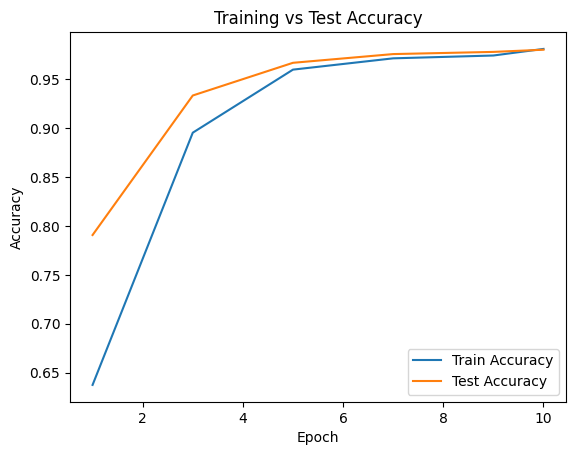

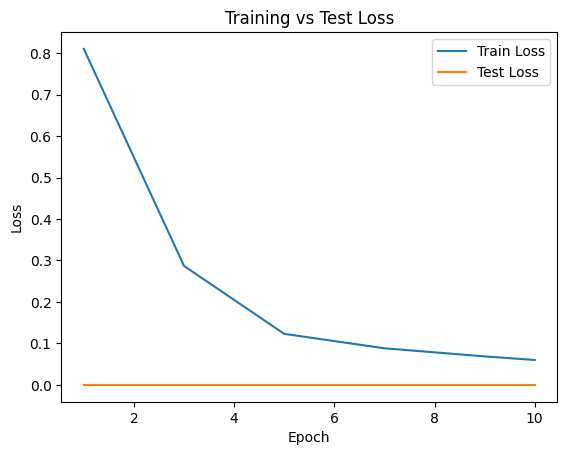

In [29]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(epoch_list, train_acc_list, label="Train Accuracy")
plt.plot(epoch_list, test_acc_list, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")
plt.legend()
plt.show()


# Loss plot
plt.figure()
plt.plot(epoch_list, train_loss_list, label="Train Loss")
plt.plot(epoch_list, test_loss_list, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.show()

## Using The Classifier

Now that we finished training the LLM, let us actually try to use it.

In [27]:
def classify(text, model, tokenizer, max_len):

    model.eval()

    ids = tokenizer.encode(text)[:max_len]
    ids_tensor = torch.tensor(ids).unsqueeze(0)

    with torch.no_grad():
        logits = model(ids_tensor)[:, -1, :]
        preds = torch.argmax(logits, dim=-1)

    if preds.item() == 1:
        return "spam"
    else:
        return "not spam"

In [28]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify(text_1, model, tokenizer, 100))

text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify(text_2, model, tokenizer, 100))

spam
spam


This is all cool and fun (and doesn't work correctly, as you saw with text_2), but we still don't have the ability to talk with the LLM, which is what we will do in the next chapter.